# UCI Part 1: Social Activity Field

This notebook includes two sections: definition of social activity field and its parameter selection.

We need a **Social Activity Field** because raw social-media post counts are sparse, uneven, and highly sensitive to platform usage noise at individual points. If we model directly on raw counts, local outliers and sampling bias can dominate patterns and weaken comparability across locations and activities. The field representation smooths nearby observations into a continuous spatial signal, preserving broad hotspots while reducing random fluctuations, so subsequent UCI modelling and optimisation are more stable and interpretable.

This notebook builds activity field targets only, keeps geospatial features as original values, and exports a unified modelling GeoPackage.

Primary handover fields:
- Index for the location: `id`
- Raw activity columns: `eating`, `nature`, `community`, `walking`, `sightseeing`
- Activity-field columns: `eating_field`, `nature_field`, `community_field`, `walking_field`, `sightseeing_field`
- Geospatial feature columns: `SP_*`, `FC_*`, `AC_*`, `CD_*` (original feature values)
- Coordinates: `longitude`, `latitude`
- Geometry: `geometry`

Data sources used in this notebook:
- `data/data_social_activity.gpkg`
- `data/data_geospatial.gpkg`

Run the export code cell to save unified output to:
- `data/data_uci_modelling.gpkg`


# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** Sijie Yang, Zdravko Trivic, Yihan Zhu, Mahmoud Abdelrahman, Filip Biljecki*

by Urban Analytics Lab, National University of Singapore

---

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).

## 1. Definition

At grid/location $\mathbf{u}$ for activity category $i$, the raw social activity intensity is directly measured by post counts:

$$
\text{SocialActivityIntensity}_{i,\mathbf{u}} = \text{PostNum}_{i,\mathbf{u}}
$$

Because raw counts are typically sparse and sensitive to local random fluctuation, we model neighborhood diffusion and spillover by defining a **Social Activity Field**:

$$
\widetilde{\text{SocialActivityField}}_{i,\mathbf{u}} = \sum_{\mathbf{v} \in \mathcal{U}} K_\sigma\!\left(d(\mathbf{u},\mathbf{v})\right)\,\text{SocialActivityIntensity}_{i,\mathbf{v}}
$$

where $K_\sigma(\cdot)$ is a Gaussian kernel and $d(\mathbf{u},\mathbf{v})$ is spatial distance. The kernel is:

$$
K_\sigma(r)=\frac{1}{\sqrt{2\pi}\sigma}\exp\!\left(-\frac{r^2}{2\sigma^2}\right),\quad r=d(\mathbf{u},\mathbf{v}).
$$

This implies that nearby grids (small $r$) receive larger weights, while distant grids decay exponentially in influence.

We then align the activity field back to the original distribution scale and enforce non-negativity:

$$
\text{SocialActivityField}_{i,\mathbf{u}} = \max\left(0,\;\frac{\widetilde{\text{SocialActivityField}}_{i,\mathbf{u}}-\mu_{\widetilde{i}}}{\sigma_{\widetilde{i}}+\varepsilon}\sigma_i+\mu_i\right).
$$

Here, $\mu_i,\sigma_i$ are the mean and standard deviation of the raw distribution for category $i$, $\mu_{\widetilde{i}},\sigma_{\widetilde{i}}$ are the corresponding statistics after activity field transformation, and $\varepsilon$ is a numerical stability term.

Parameter settings used in this study (consistent with code):
- `grid_base = 500`: baseline grid resolution. The algorithm adaptively computes `(x_grid_size, y_grid_size)` from the longitude-latitude aspect ratio to preserve spatial shape.
- `sigma = 5.0`: Gaussian kernel standard deviation in **grid-cell units**. Larger $\sigma$ yields stronger spatial diffusion and broader field surfaces; smaller $\sigma$ preserves sharper local peaks.

Why this transformation is used:
- reduce sparsity and local noise in post-count signals;
- preserve neighborhood influence so the metric behaves as a spatial activity field rather than isolated point counts;
- provide a more stable and interpretable exposure variable for downstream causal analysis.


In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import ndimage
from sklearn.preprocessing import StandardScaler

# -------------------------
# Config
# -------------------------
FX_SOCIAL_FILE_PATH = "data/data_social_activity.gpkg"
FX_GEOSPATIAL_FILE_PATH = "data/data_geospatial.gpkg"
FX_ACT_COLUMNS = ["eating", "nature", "community", "walking", "sightseeing"]
FX_DIMENSION_FEATURES = {
    "SP": ["SP_1-E_comfort", "SP_2-E_sunshine_intensity", "SP_3-E_temp_inference", "SP_4-E_humidity_inference", "SP_5-E_wind_inference", "SP_6-E_greenery_rate", "SP_7-E_shading_area", "SP_8-E_heat_source", "SP_9-E_traffic_flow", "SP_1-D_imageability", "SP_2-D_enclosure", "SP_3-D_human_scale", "SP_4-D_complexity"],
    "FC": ["FC_1-R_eating_rating", "FC_1-D_eating_density", "FC_2-R_retail_rating", "FC_2-D_retail_density", "FC_3-R_life_rating", "FC_3-D_life_density", "FC_4-R_recreation_rating", "FC_4-D_recreation_density", "FC_5-R_health_rating", "FC_5-D_health_density", "FC_6-R_community_rating", "FC_6-D_community_density", "FC_7-R_trans_rating", "FC_7-D_trans_density", "FC_1-H_HDB_density", "FC_1-G_review_polarity", "FC_2-G_review_subjectivity"],
    "AC": ["AC_1-L_closeness400", "AC_2-L_closeness800", "AC_1-G_closeness2000", "AC_2-G_closeness6000", "AC_1-T_subway_accessibility", "AC_2-T_subway_density", "AC_3-T_bus_accessibility", "AC_4-T_bus_density"],
    "CD": ["CD_1-P_population", "CD_1-B_building_density", "CD_1-L_leisure_density"],
}

# Baseline values used in code.ipynb
FX_BASE_GRID_BASE = 500
FX_BASE_SIGMA = 5.0


In [2]:
# -------------------------
# Core activity field function (aligned with original implementation)
# -------------------------
def fx_gaussian_grid_smooth(temp_df, target_col, grid_base=500, sigma=5.0):
    x_min, x_max = temp_df["longitude"].min(), temp_df["longitude"].max()
    y_min, y_max = temp_df["latitude"].min(), temp_df["latitude"].max()

    x_range = x_max - x_min
    y_range = y_max - y_min
    if x_range == 0 or y_range == 0:
        return temp_df[target_col].values.astype(float)

    aspect_ratio = x_range / y_range
    if aspect_ratio > 1:
        x_grid_size = int(grid_base)
        y_grid_size = max(2, int(grid_base / aspect_ratio))
    else:
        y_grid_size = int(grid_base)
        x_grid_size = max(2, int(grid_base * aspect_ratio))

    x_grid = np.linspace(x_min, x_max, x_grid_size)
    y_grid = np.linspace(y_min, y_max, y_grid_size)
    grid = np.zeros((y_grid_size, x_grid_size), dtype=float)

    for _, row in temp_df.iterrows():
        x_idx = int((row["longitude"] - x_min) / x_range * (x_grid_size - 1))
        y_idx = int((row["latitude"] - y_min) / y_range * (y_grid_size - 1))
        grid[y_idx, x_idx] += row[target_col]

    smoothed_grid = ndimage.gaussian_filter(grid, sigma=sigma)

    smoothed_values = []
    for _, row in temp_df.iterrows():
        x_idx = int((row["longitude"] - x_min) / x_range * (x_grid_size - 1))
        y_idx = int((row["latitude"] - y_min) / y_range * (y_grid_size - 1))
        smoothed_values.append(smoothed_grid[y_idx, x_idx])

    smoothed_values = np.asarray(smoothed_values, dtype=float)

    # Match raw distribution (mean/std)
    raw = temp_df[target_col].values.astype(float)
    raw_mean, raw_std = np.mean(raw), np.std(raw)
    sm_mean, sm_std = np.mean(smoothed_values), np.std(smoothed_values)

    if sm_std > 0:
        normalized = ((smoothed_values - sm_mean) / sm_std) * raw_std + raw_mean
    else:
        normalized = np.full_like(smoothed_values, fill_value=raw_mean)

    # Enforce nonnegative
    min_val = np.min(normalized)
    if min_val < 0:
        normalized = normalized - min_val

    return normalized


In [3]:
# -------------------------
# Data load + baseline extraction (activity field + original features)
# -------------------------
fx_social_gdf = gpd.read_file(FX_SOCIAL_FILE_PATH)
fx_geo_gdf = gpd.read_file(FX_GEOSPATIAL_FILE_PATH)

for _gdf in [fx_social_gdf, fx_geo_gdf]:
    if _gdf.crs is None:
        _gdf.set_crs("EPSG:4326", inplace=True)
    elif _gdf.crs.to_string() != "EPSG:4326":
        _gdf.to_crs("EPSG:4326", inplace=True)

if "longitude" in fx_geo_gdf.columns and "latitude" in fx_geo_gdf.columns:
    fx_geo_gdf["longitude"] = fx_geo_gdf["longitude"].astype(float)
    fx_geo_gdf["latitude"] = fx_geo_gdf["latitude"].astype(float)
else:
    fx_geo_gdf["longitude"] = fx_geo_gdf.geometry.x.astype(float)
    fx_geo_gdf["latitude"] = fx_geo_gdf.geometry.y.astype(float)

social_cols = ["id"] + [c for c in FX_ACT_COLUMNS if c in fx_social_gdf.columns]
missing_acts = [c for c in FX_ACT_COLUMNS if c not in social_cols]
if missing_acts:
    raise RuntimeError(f"Missing activity columns in social activity source: {missing_acts}")

fx_gdf = fx_geo_gdf.merge(fx_social_gdf[social_cols], on="id", how="inner")

fx_expected_features = sum(FX_DIMENSION_FEATURES.values(), [])
fx_available_features = [c for c in fx_expected_features if c in fx_gdf.columns]

# Build activity field variables -> *_field
for act in FX_ACT_COLUMNS:
    temp_df = (
        fx_gdf[["longitude", "latitude", act]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["longitude", "latitude", act])
        .copy()
    )
    fx_gdf.loc[temp_df.index, f"{act}_field"] = fx_gaussian_grid_smooth(
        temp_df,
        act,
        grid_base=FX_BASE_GRID_BASE,
        sigma=FX_BASE_SIGMA,
    )

fx_use_cols = (
    FX_ACT_COLUMNS
    + fx_available_features
    + ["longitude", "latitude"]
    + [f"{act}_field" for act in FX_ACT_COLUMNS]
)

fx_df = (
    fx_gdf[fx_use_cols + ["geometry"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=fx_use_cols + ["geometry"])
    .copy()
)
if fx_df.geometry.is_empty.any():
    fx_df = fx_df.loc[~fx_df.geometry.is_empty].copy()

fx_coords = np.column_stack([fx_df["longitude"].values, fx_df["latitude"].values])
fx_x_scaled_df = pd.DataFrame(
    StandardScaler().fit_transform(fx_df[fx_available_features].values),
    columns=fx_available_features,
    index=fx_df.index,
)

print(f"Social source: {FX_SOCIAL_FILE_PATH}")
print(f"Geospatial source: {FX_GEOSPATIAL_FILE_PATH}")
print(f"UCI modelling table ready: rows={len(fx_df)}, features={len(fx_available_features)}")
print(f"Baseline activity field parameters: grid_base={FX_BASE_GRID_BASE}, sigma={FX_BASE_SIGMA}")


Social source: data/data_social_activity.gpkg
Geospatial source: data/data_geospatial.gpkg
UCI modelling table ready: rows=2096, features=41
Baseline activity field parameters: grid_base=500, sigma=5.0


## 2. Integrated Sensitivity + Regression Evaluation for Parameter Selection

This section runs one continuous pipeline:
- Spatial sensitivity metrics (`corr`, `mae`, `top10_overlap`)
- Feature-based linear regression fit metrics (`r2`, `rmse`, `mae_reg`)
- Joint ranking and threshold-based final selection

All steps are executed in sequence without splitting into separate analysis sections.


### 2.1 Method Boundaries and Bias Risks

- **Platform and population bias**: social-media activity does not represent all demographic groups equally, so the field should be interpreted as a proxy of observed digital activity rather than complete social participation.
- **Temporal sampling bias**: posting behavior varies by time-of-day, weekday/weekend, and events. If data are temporally imbalanced, the resulting field may overstate certain periods.
- **Field-transformation trade-off in sparse areas**: stronger diffusion can improve stability but may blur local heterogeneity and create over-diffused hotspots in low-sample regions.

These limits do not invalidate the method, but they should be explicitly considered when comparing places or deriving planning recommendations.


### 2.2 Explicit Parameter Selection Rule

The notebook computes a normalized joint score from Section 2B using the following weights:
- `corr_mean_norm`: 0.25 (higher is better)
- `hotspot_overlap_mean_norm`: 0.25 (higher is better)
- `r2_mean_norm`: 0.30 (higher is better)
- `rmse_mean_norm`: 0.10 (lower is better; inverted after normalization)
- `mae_reg_mean_norm`: 0.10 (lower is better; inverted after normalization)

Threshold screening in Section 2E is:
- `corr_mean >= 0.70`
- `hotspot_overlap_mean >= 0.50`
- `r2_mean >= 0.50`

Among qualified candidates, settings are sorted by `r2_mean` (descending), `overall_joint_score` (descending), `rmse_mean` (ascending), and `mae_reg_mean` (ascending).


In [4]:
# -------------------------
# 2A) Settings + helpers for sensitivity and regression
# -------------------------
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

SIGMA_CANDIDATES = [2.0, 3.0, 5.0, 7.0, 10.0]
GRID_BASE_CANDIDATES = [300, 500, 700]
TOP_FRAC = 0.10


def _safe_corr(a, b):
    if len(a) < 2:
        return np.nan
    a_std = np.std(a)
    b_std = np.std(b)
    if a_std == 0 or b_std == 0:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])


def _top_overlap_ratio(raw, ext, top_frac=0.10):
    n = len(raw)
    if n == 0:
        return np.nan
    k = max(1, int(np.ceil(n * top_frac)))
    raw_idx = np.argpartition(raw, -k)[-k:]
    ext_idx = np.argpartition(ext, -k)[-k:]
    overlap = len(set(raw_idx).intersection(set(ext_idx)))
    return overlap / k


def evaluate_one_setting(gdf, act_columns, sigma, grid_base):
    rows = []
    for act in act_columns:
        temp_df = (
            gdf[["longitude", "latitude", act]]
            .replace([np.inf, -np.inf], np.nan)
            .dropna(subset=["longitude", "latitude", act])
            .copy()
        )
        raw = temp_df[act].values.astype(float)
        ext = fx_gaussian_grid_smooth(temp_df, act, grid_base=grid_base, sigma=sigma)

        corr = _safe_corr(raw, ext)
        mae = float(np.mean(np.abs(ext - raw)))
        hotspot_overlap = _top_overlap_ratio(raw, ext, top_frac=TOP_FRAC)

        rows.append({
            "activity": act,
            "sigma": sigma,
            "grid_base": grid_base,
            "pearson_corr": corr,
            "mae": mae,
            "top10_overlap": hotspot_overlap,
        })
    return pd.DataFrame(rows)


def _build_xy_for_setting(gdf, activity, feature_cols, sigma, grid_base):
    cols = ["longitude", "latitude", activity] + feature_cols
    temp = (
        gdf[cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=cols)
        .copy()
    )

    if len(temp) < 3:
        return None, None

    # Build activity field target
    y = fx_gaussian_grid_smooth(
        temp[["longitude", "latitude", activity]],
        activity,
        grid_base=grid_base,
        sigma=sigma,
    )

    # Keep original feature values (no feature smoothing)
    X = temp[feature_cols].values.astype(float) if feature_cols else None
    return X, y


def evaluate_regression_one_setting(gdf, act_columns, feature_cols, sigma, grid_base):
    rows = []
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression()),
    ])

    for act in act_columns:
        X, y = _build_xy_for_setting(gdf, act, feature_cols, sigma=sigma, grid_base=grid_base)
        if X is None:
            rows.append({"activity": act, "sigma": sigma, "grid_base": grid_base, "r2": np.nan, "rmse": np.nan, "mae_reg": np.nan})
            continue

        model.fit(X, y)
        pred = model.predict(X)
        rows.append({
            "activity": act,
            "sigma": sigma,
            "grid_base": grid_base,
            "r2": float(r2_score(y, pred)),
            "rmse": float(np.sqrt(mean_squared_error(y, pred))),
            "mae_reg": float(mean_absolute_error(y, pred)),
        })
    return pd.DataFrame(rows)


In [5]:
# -------------------------
# 2B) Run sensitivity + regression and build one joint table
# -------------------------
if len(fx_available_features) == 0:
    raise RuntimeError("No available features found for regression evaluation.")

sens_parts = []
reg_parts = []
for gb in GRID_BASE_CANDIDATES:
    for sg in SIGMA_CANDIDATES:
        sens_parts.append(evaluate_one_setting(fx_gdf, FX_ACT_COLUMNS, sigma=sg, grid_base=gb))
        reg_parts.append(evaluate_regression_one_setting(fx_gdf, FX_ACT_COLUMNS, fx_available_features, sigma=sg, grid_base=gb))

sens_df = pd.concat(sens_parts, ignore_index=True)
reg_df = pd.concat(reg_parts, ignore_index=True)

summary_df = (
    sens_df.groupby(["grid_base", "sigma"], as_index=False)
    .agg(
        corr_mean=("pearson_corr", "mean"),
        corr_std=("pearson_corr", "std"),
        mae_mean=("mae", "mean"),
        hotspot_overlap_mean=("top10_overlap", "mean"),
    )
)

reg_summary_df = (
    reg_df.groupby(["grid_base", "sigma"], as_index=False)
    .agg(
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std"),
        rmse_mean=("rmse", "mean"),
        mae_reg_mean=("mae_reg", "mean"),
    )
)

joint_df = summary_df.merge(reg_summary_df, on=["grid_base", "sigma"], how="inner")

for m in ["corr_mean", "hotspot_overlap_mean", "r2_mean"]:
    mn, mx = joint_df[m].min(), joint_df[m].max()
    joint_df[f"{m}_norm"] = (joint_df[m] - mn) / (mx - mn) if mx > mn else 0.0

for m in ["mae_mean", "rmse_mean", "mae_reg_mean"]:
    mn, mx = joint_df[m].min(), joint_df[m].max()
    joint_df[f"{m}_norm"] = 1 - (joint_df[m] - mn) / (mx - mn) if mx > mn else 0.0

joint_df["overall_joint_score"] = (
    0.25 * joint_df["corr_mean_norm"]
    + 0.25 * joint_df["hotspot_overlap_mean_norm"]
    + 0.30 * joint_df["r2_mean_norm"]
    + 0.10 * joint_df["rmse_mean_norm"]
    + 0.10 * joint_df["mae_reg_mean_norm"]
)

joint_df = joint_df.sort_values(["grid_base", "sigma"]).reset_index(drop=True)
display(joint_df)


,grid_base,sigma,corr_mean,corr_std,mae_mean,hotspot_overlap_mean,r2_mean,r2_std,rmse_mean,mae_reg_mean,corr_mean_norm,hotspot_overlap_mean_norm,r2_mean_norm,mae_mean_norm,rmse_mean_norm,mae_reg_mean_norm,overall_joint_score
0,300,2.0,0.898609,0.006512,1.792953,0.749524,0.376096,0.148457,3.421259,2.377602,0.835548,0.705111,0.327449,0.701464,0.283024,0.255167,0.537219
1,300,3.0,0.718388,0.013549,3.193695,0.532381,0.510862,0.177519,2.976182,2.162821,0.536754,0.406291,0.585844,0.464462,0.532413,0.481792,0.512935
2,300,5.0,0.547008,0.042003,4.554908,0.380000,0.634985,0.184127,2.518788,1.898457,0.252620,0.196592,0.823833,0.234147,0.788702,0.760734,0.514397
3,300,7.0,0.464410,0.062609,5.312614,0.288571,0.689436,0.178855,2.297761,1.776242,0.115678,0.070773,0.928235,0.105945,0.912550,0.889689,0.505307
4,300,10.0,0.394638,0.075400,5.938773,0.237143,0.726865,0.169997,2.141691,1.671697,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.500000
5,500,2.0,0.997267,0.001433,0.136330,0.960952,0.217340,0.092110,3.892901,2.598954,0.999117,0.996068,0.023058,0.981762,0.018750,0.021607,0.509749
6,500,3.0,0.952544,0.001946,1.267375,0.847619,0.329404,0.134291,3.565217,2.425572,0.924969,0.840105,0.237925,0.790391,0.202360,0.204551,0.553337
7,500,5.0,0.722207,0.015565,3.201829,0.549524,0.515629,0.181602,2.955798,2.150253,0.543087,0.429882,0.594984,0.463085,0.543834,0.495053,0.525626
8,500,7.0,0.597590,0.032523,4.119361,0.431429,0.598091,0.188350,2.655998,1.981234,0.336480,0.267366,0.753094,0.307841,0.711820,0.673393,0.515411
9,500,10.0,0.499558,0.054245,4.978360,0.328571,0.664477,0.185372,2.395977,1.830311,0.173950,0.125819,0.880381,0.162500,0.857517,0.832638,0.508072


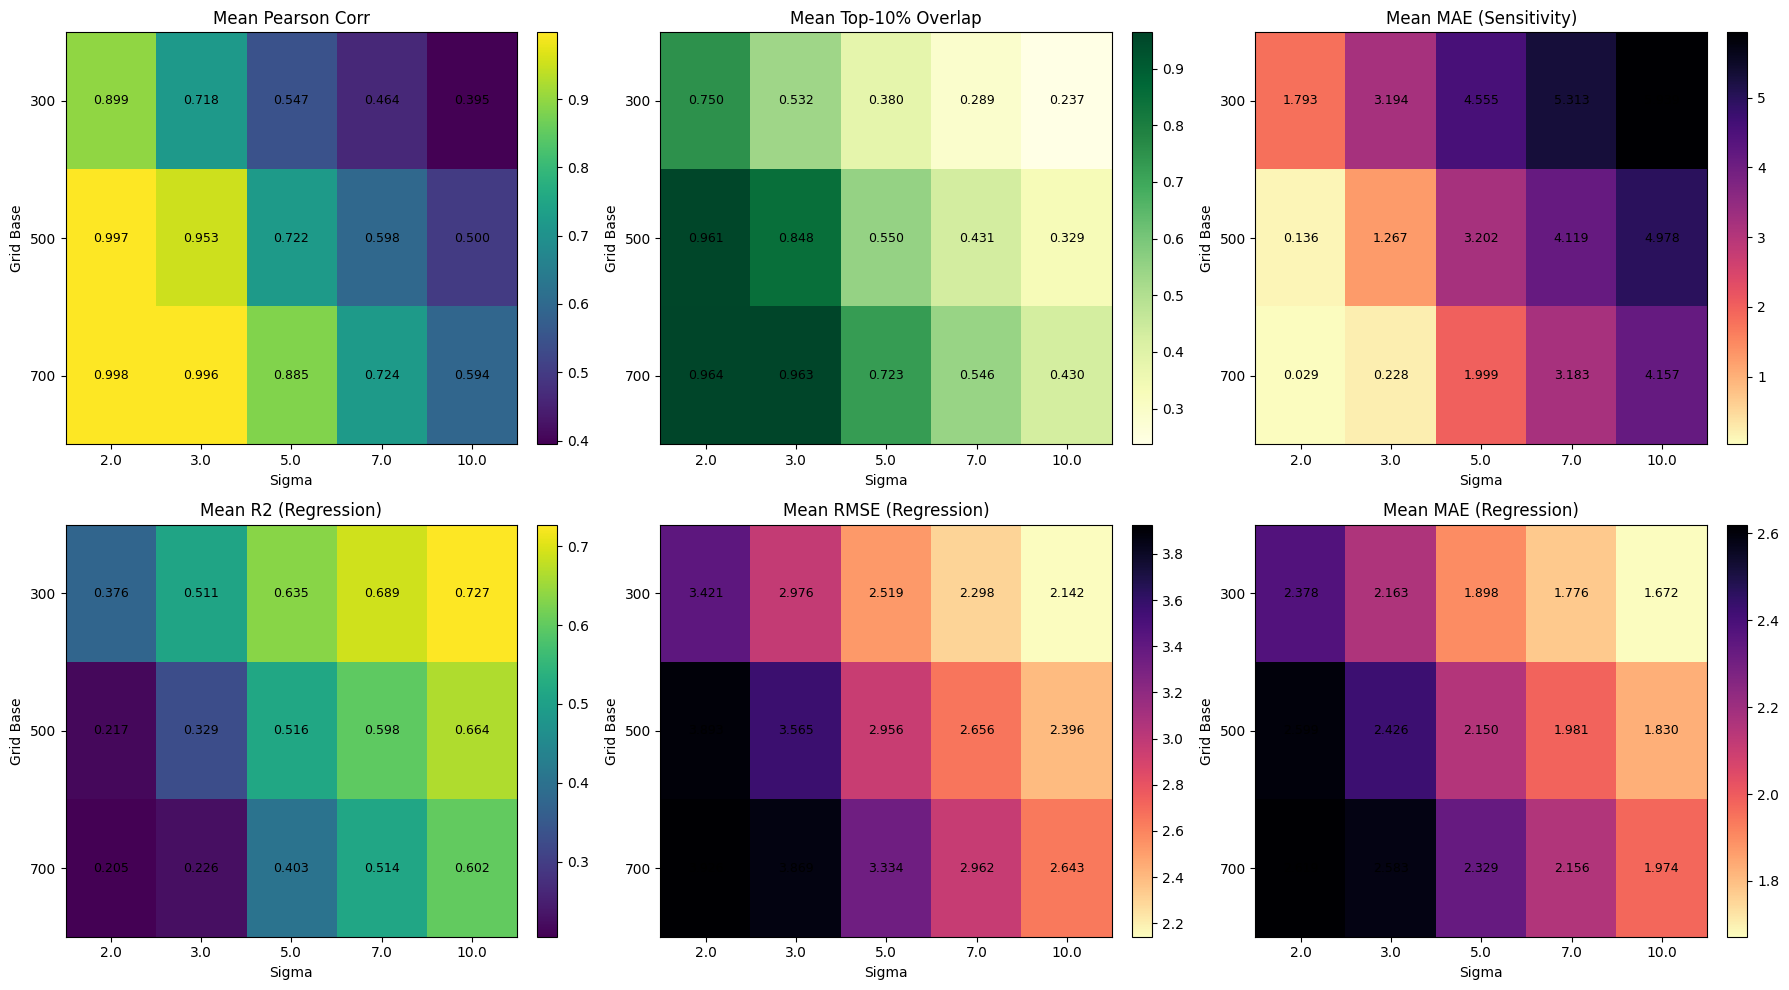

In [6]:
# -------------------------
# 2C) One visualization block (joint metrics heatmaps)
# -------------------------
viz_metrics = [
    ("corr_mean", "Mean Pearson Corr", "viridis"),
    ("hotspot_overlap_mean", "Mean Top-10% Overlap", "YlGn"),
    ("mae_mean", "Mean MAE (Sensitivity)", "magma_r"),
    ("r2_mean", "Mean R2 (Regression)", "viridis"),
    ("rmse_mean", "Mean RMSE (Regression)", "magma_r"),
    ("mae_reg_mean", "Mean MAE (Regression)", "magma_r"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (metric, title, cmap) in zip(axes, viz_metrics):
    mat = joint_df.pivot(index="grid_base", columns="sigma", values=metric).sort_index().sort_index(axis=1)
    arr = mat.values
    im = ax.imshow(arr, aspect="auto", cmap=cmap)

    ax.set_title(title)
    ax.set_xlabel("Sigma")
    ax.set_ylabel("Grid Base")
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels([str(x) for x in mat.columns])
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels([str(y) for y in mat.index])

    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            ax.text(j, i, f"{arr[i, j]:.3f}", ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


,grid_base,sigma,corr_mean,corr_std,mae_mean,hotspot_overlap_mean,r2_mean,r2_std,rmse_mean,mae_reg_mean,corr_mean_norm,hotspot_overlap_mean_norm,r2_mean_norm,mae_mean_norm,rmse_mean_norm,mae_reg_mean_norm,overall_joint_score
5,500,2.0,0.997267,0.001433,0.136330,0.960952,0.217340,0.092110,3.892901,2.598954,0.999117,0.996068,0.023058,0.981762,0.018750,0.021607,0.509749
6,500,3.0,0.952544,0.001946,1.267375,0.847619,0.329404,0.134291,3.565217,2.425572,0.924969,0.840105,0.237925,0.790391,0.202360,0.204551,0.553337
7,500,5.0,0.722207,0.015565,3.201829,0.549524,0.515629,0.181602,2.955798,2.150253,0.543087,0.429882,0.594984,0.463085,0.543834,0.495053,0.525626
8,500,7.0,0.597590,0.032523,4.119361,0.431429,0.598091,0.188350,2.655998,1.981234,0.336480,0.267366,0.753094,0.307841,0.711820,0.673393,0.515411
9,500,10.0,0.499558,0.054245,4.978360,0.328571,0.664477,0.185372,2.395977,1.830311,0.173950,0.125819,0.880381,0.162500,0.857517,0.832638,0.508072


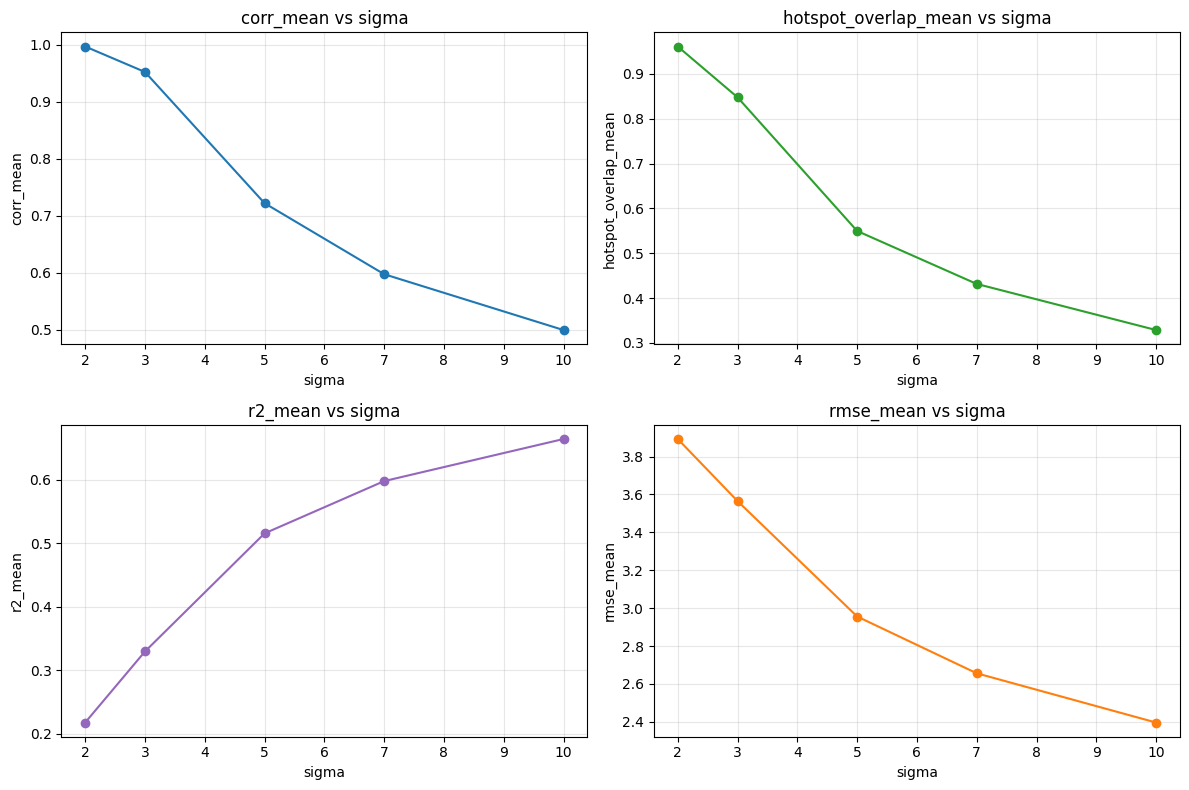

In [7]:
# -------------------------
# 2D) Focus view (grid_base = 500)
# -------------------------
FOCUS_GRID_BASE = 500
focus_df = joint_df[joint_df["grid_base"] == FOCUS_GRID_BASE].copy().sort_values("sigma")
display(focus_df)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(focus_df["sigma"], focus_df["corr_mean"], marker="o")
axes[0, 0].set_title("corr_mean vs sigma")
axes[0, 0].set_xlabel("sigma")
axes[0, 0].set_ylabel("corr_mean")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(focus_df["sigma"], focus_df["hotspot_overlap_mean"], marker="o", color="tab:green")
axes[0, 1].set_title("hotspot_overlap_mean vs sigma")
axes[0, 1].set_xlabel("sigma")
axes[0, 1].set_ylabel("hotspot_overlap_mean")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(focus_df["sigma"], focus_df["r2_mean"], marker="o", color="tab:purple")
axes[1, 0].set_title("r2_mean vs sigma")
axes[1, 0].set_xlabel("sigma")
axes[1, 0].set_ylabel("r2_mean")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(focus_df["sigma"], focus_df["rmse_mean"], marker="o", color="tab:orange")
axes[1, 1].set_title("rmse_mean vs sigma")
axes[1, 1].set_xlabel("sigma")
axes[1, 1].set_ylabel("rmse_mean")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
# -------------------------
# 2E) Final recommendation (threshold-based)
# -------------------------
THR_CORR = 0.70
THR_HOTSPOT = 0.50
THR_R2 = 0.50

joint_filtered = joint_df[
    (joint_df["corr_mean"] >= THR_CORR)
    & (joint_df["hotspot_overlap_mean"] >= THR_HOTSPOT)
    & (joint_df["r2_mean"] >= THR_R2)
].copy()

joint_filtered = joint_filtered.sort_values(
    ["r2_mean", "overall_joint_score", "rmse_mean", "mae_reg_mean"],
    ascending=[False, False, True, True],
)

print(f"Thresholds: corr_mean>={THR_CORR}, hotspot_overlap_mean>={THR_HOTSPOT}, r2_mean>={THR_R2}")
print(f"Candidates after thresholding: {len(joint_filtered)}")
display(joint_filtered)

if len(joint_filtered) > 0:
    best = joint_filtered.iloc[0][["grid_base", "sigma", "corr_mean", "hotspot_overlap_mean", "r2_mean", "overall_joint_score"]]
    print("Final recommended setting:")
    display(best.to_frame().T)
else:
    print("No setting satisfies all thresholds. Consider relaxing thresholds.")


Thresholds: corr_mean>=0.7, hotspot_overlap_mean>=0.5, r2_mean>=0.5
Candidates after thresholding: 3


,grid_base,sigma,corr_mean,corr_std,mae_mean,hotspot_overlap_mean,r2_mean,r2_std,rmse_mean,mae_reg_mean,corr_mean_norm,hotspot_overlap_mean_norm,r2_mean_norm,mae_mean_norm,rmse_mean_norm,mae_reg_mean_norm,overall_joint_score
7,500,5.0,0.722207,0.015565,3.201829,0.549524,0.515629,0.181602,2.955798,2.150253,0.543087,0.429882,0.594984,0.463085,0.543834,0.495053,0.525626
13,700,7.0,0.724489,0.015033,3.182596,0.545714,0.514223,0.181590,2.961746,2.155667,0.546869,0.424640,0.592289,0.466339,0.540501,0.489341,0.523548
1,300,3.0,0.718388,0.013549,3.193695,0.532381,0.510862,0.177519,2.976182,2.162821,0.536754,0.406291,0.585844,0.464462,0.532413,0.481792,0.512935


Final recommended setting:


,grid_base,sigma,corr_mean,hotspot_overlap_mean,r2_mean,overall_joint_score
7,500.0,5.0,0.722207,0.549524,0.515629,0.525626


## 3. Social Activity Field Visualization

This block compares raw social activity intensity and social activity field for each activity, including map views and raw-vs-field scatter diagnostics.


/var/folders/f4/33sk92_n60j6tssngt9ntw3m0000gn/T/ipykernel_1988/1675419458.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


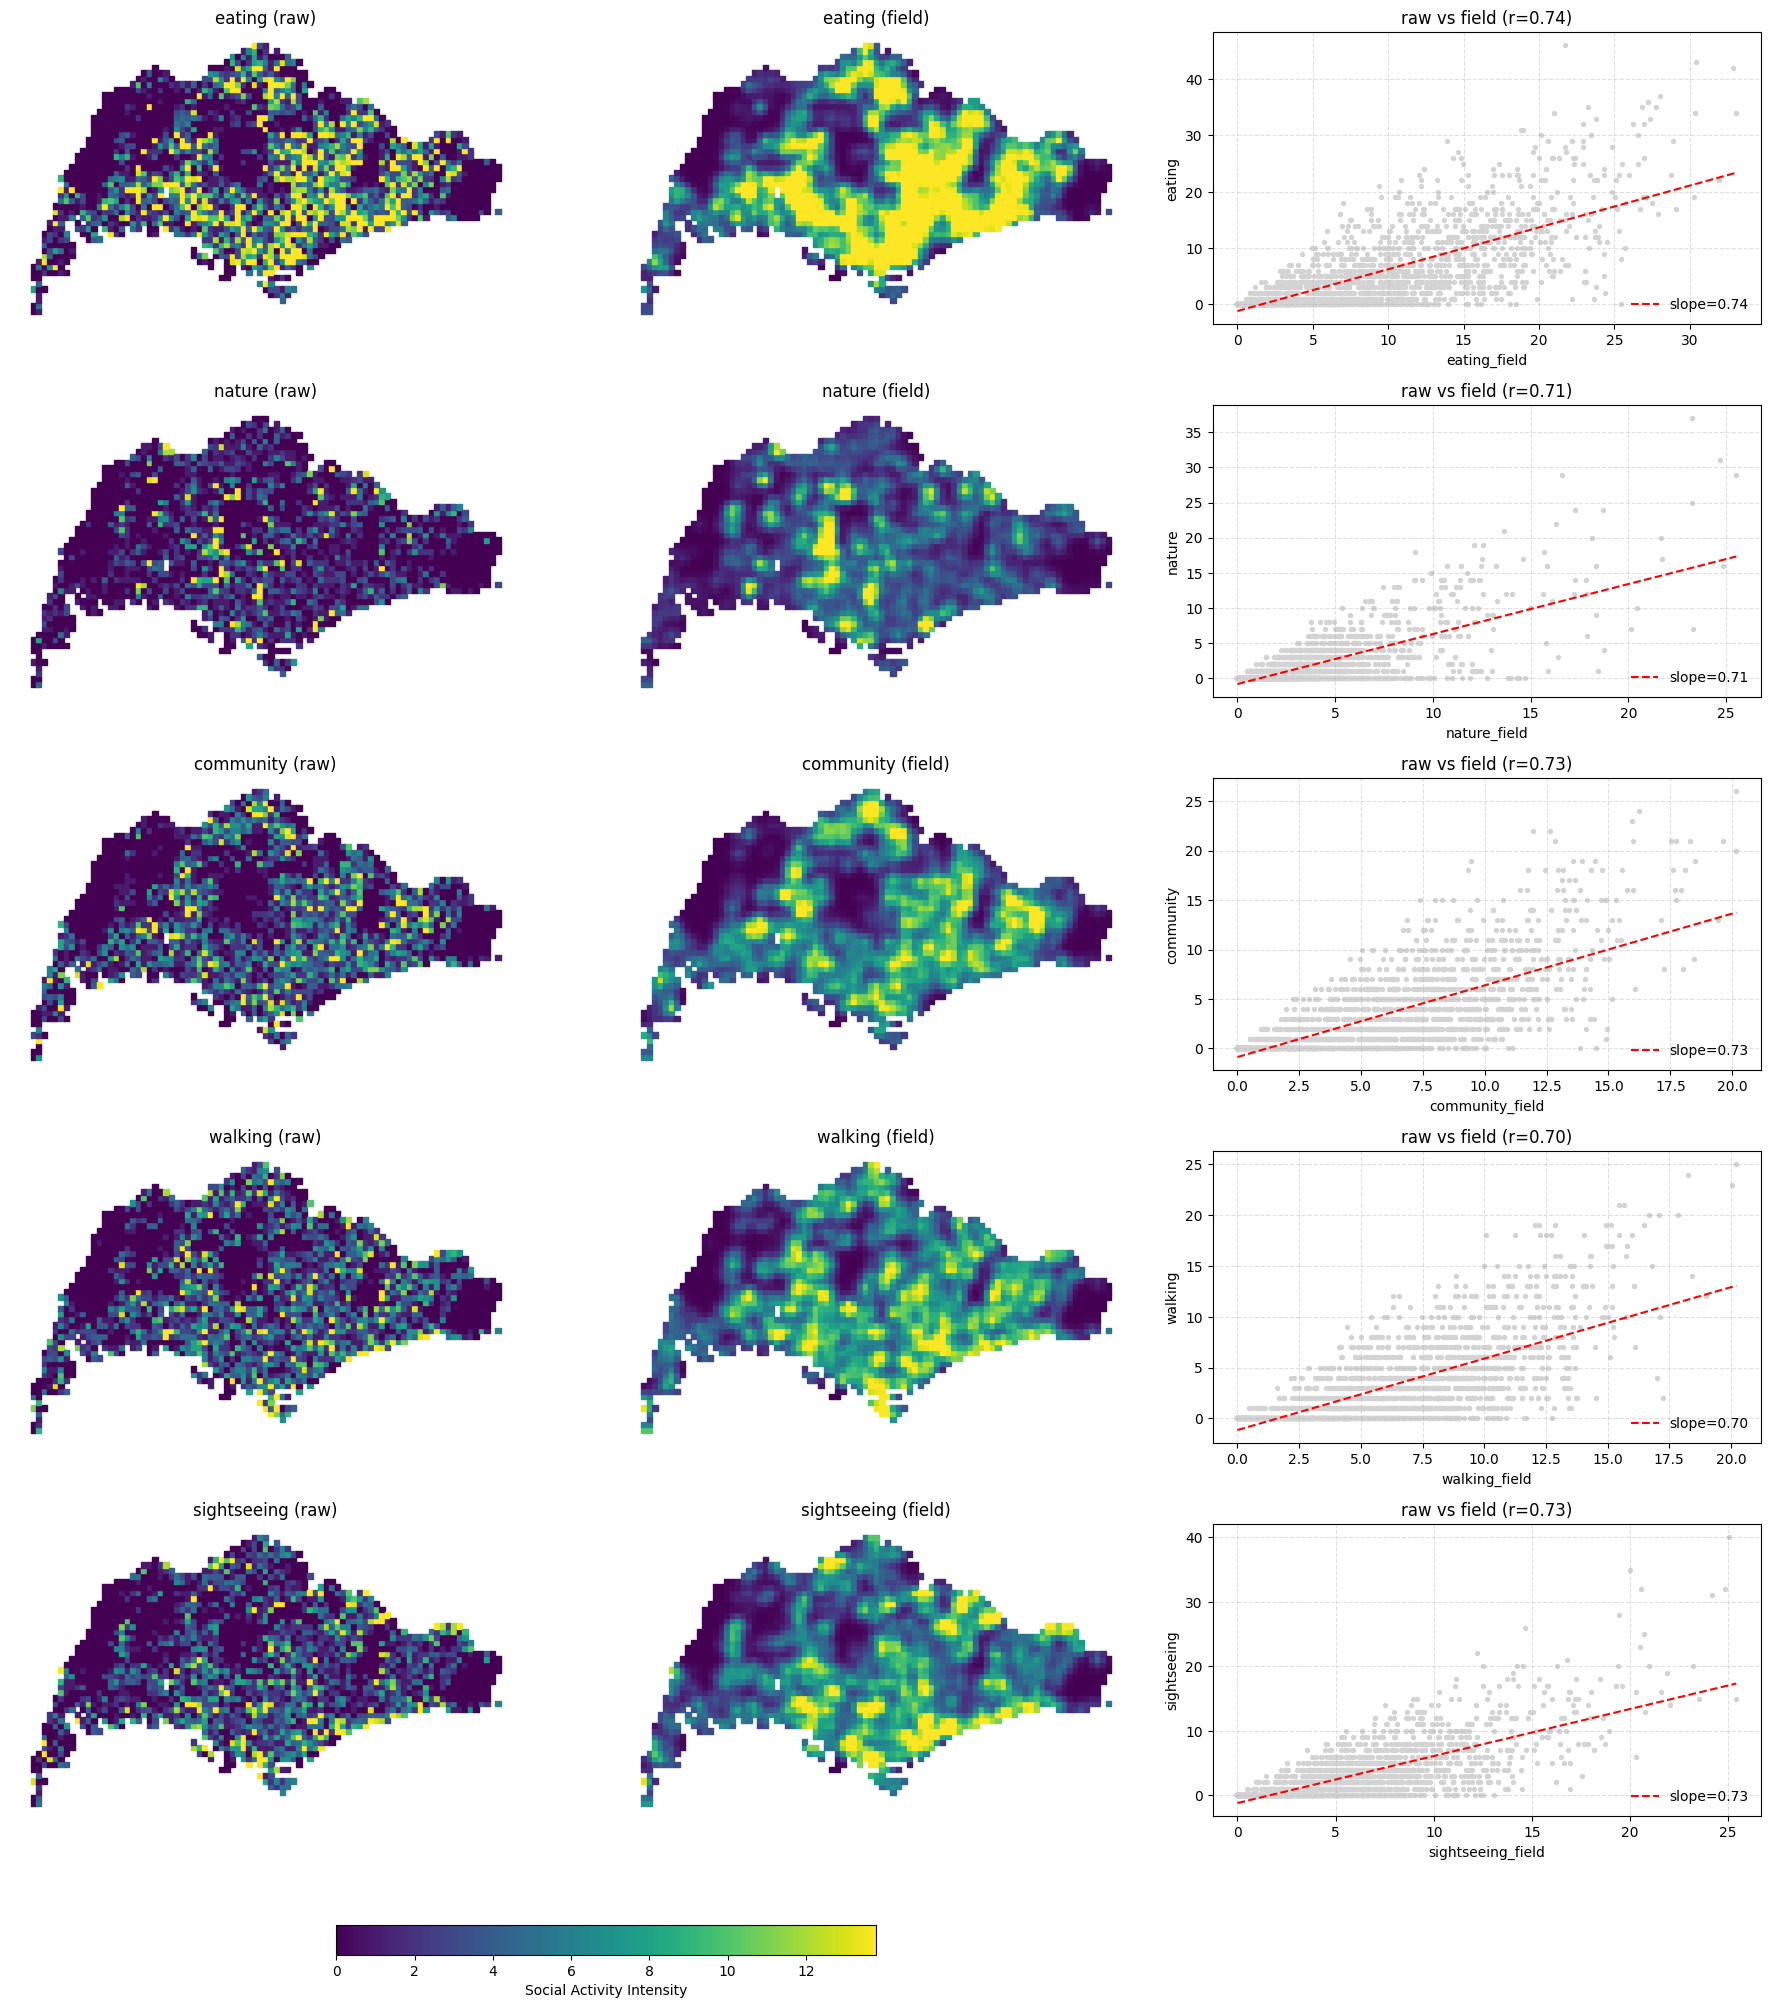

Original and raw and field target variable list:
['eating', 'nature', 'community', 'walking', 'sightseeing', 'eating_field', 'nature_field', 'community_field', 'walking_field', 'sightseeing_field']
===== Raw Value Description =====
eating (raw) describe():
count    2096.000000
mean        4.920324
std         6.741376
min         0.000000
25%         0.000000
50%         2.000000
75%         7.000000
max        46.000000
Name: eating, dtype: float64
nature (raw) describe():
count    2096.000000
mean        1.829198
std         3.382593
min         0.000000
25%         0.000000
50%         0.000000
75%         2.000000
max        37.000000
Name: nature, dtype: float64
community (raw) describe():
count    2096.000000
mean        3.076813
std         4.029523
min         0.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        26.000000
Name: community, dtype: float64
walking (raw) describe():
count    2096.000000
mean        3.086832
std         3.931890
min    

In [9]:
# -------------------------
# 3A) Social Activity Field Visualization: social activity raw vs social activity field
# -------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl

if "fx_df" not in globals():
    raise RuntimeError("Please run the Social Activity Field block first.")

missing_field = [act for act in FX_ACT_COLUMNS if f"{act}_field" not in fx_df.columns]
if missing_field:
    raise RuntimeError(f"Missing field columns: {missing_field}. Re-run Social Activity Field block.")

n_acts = len(FX_ACT_COLUMNS)
fig, axes = plt.subplots(n_acts, 3, figsize=(18, 4 * n_acts))
if n_acts == 1:
    axes = np.array([axes])

# Shared color scale for raw/field maps
all_vals = []
for act in FX_ACT_COLUMNS:
    all_vals.extend(fx_df[act].values.tolist())
    all_vals.extend(fx_df[f"{act}_field"].values.tolist())
vmin = float(np.nanmin(all_vals))
vmax = float(np.nanmax(all_vals)) * 0.3 # Set a cap for clear visualisation

for r, act in enumerate(FX_ACT_COLUMNS):
    raw_col = act
    sm_col = f"{act}_field"

    ax_raw, ax_smooth, ax_scatter = axes[r, 0], axes[r, 1], axes[r, 2]

    fx_df.plot(
        ax=ax_raw,
        column=raw_col,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        marker="s",
        markersize=15,
        legend=False,
    )
    ax_raw.set_title(f"{act} (raw)")
    ax_raw.set_axis_off()

    fx_df.plot(
        ax=ax_smooth,
        column=sm_col,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        marker="s",
        markersize=15,
        legend=False,
    )
    ax_smooth.set_title(f"{act} (field)")
    ax_smooth.set_axis_off()

    x = fx_df[sm_col].values
    y = fx_df[raw_col].values
    ax_scatter.scatter(x, y, color="lightgrey", s=8)
    b, a = np.polyfit(x, y, 1)
    xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ax_scatter.plot(xx, a + b * xx, "r--", linewidth=1.5, label=f"slope={b:.2f}")
    corr = np.corrcoef(x, y)[0, 1]
    ax_scatter.set_title(f"raw vs field (r={corr:.2f})")
    ax_scatter.set_xlabel(f"{act}_field")
    ax_scatter.set_ylabel(act)
    ax_scatter.grid(True, linestyle="--", alpha=0.4)
    ax_scatter.legend(loc="lower right", frameon=False)

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

# Put colorbar at the very bottom to avoid overlap with scatter panels
fig.subplots_adjust(bottom=0.08)
cbar_ax = fig.add_axes([0.2, 0.02, 0.3, 0.015])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Social Activity Intensity")

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

print("Original and raw and field target variable list:")
print(FX_ACT_COLUMNS + [f"{act}_field" for act in FX_ACT_COLUMNS])

# Print value descriptions for raw and extracted data
print("===== Raw Value Description =====")
for act in FX_ACT_COLUMNS:
    print(f"{act} (raw) describe():")
    print(fx_df[act].describe())

print("===== Field Value Description =====")
for act in FX_ACT_COLUMNS:
    print(f"{act}_field describe():")
    print(fx_df[f'{act}_field'].describe())



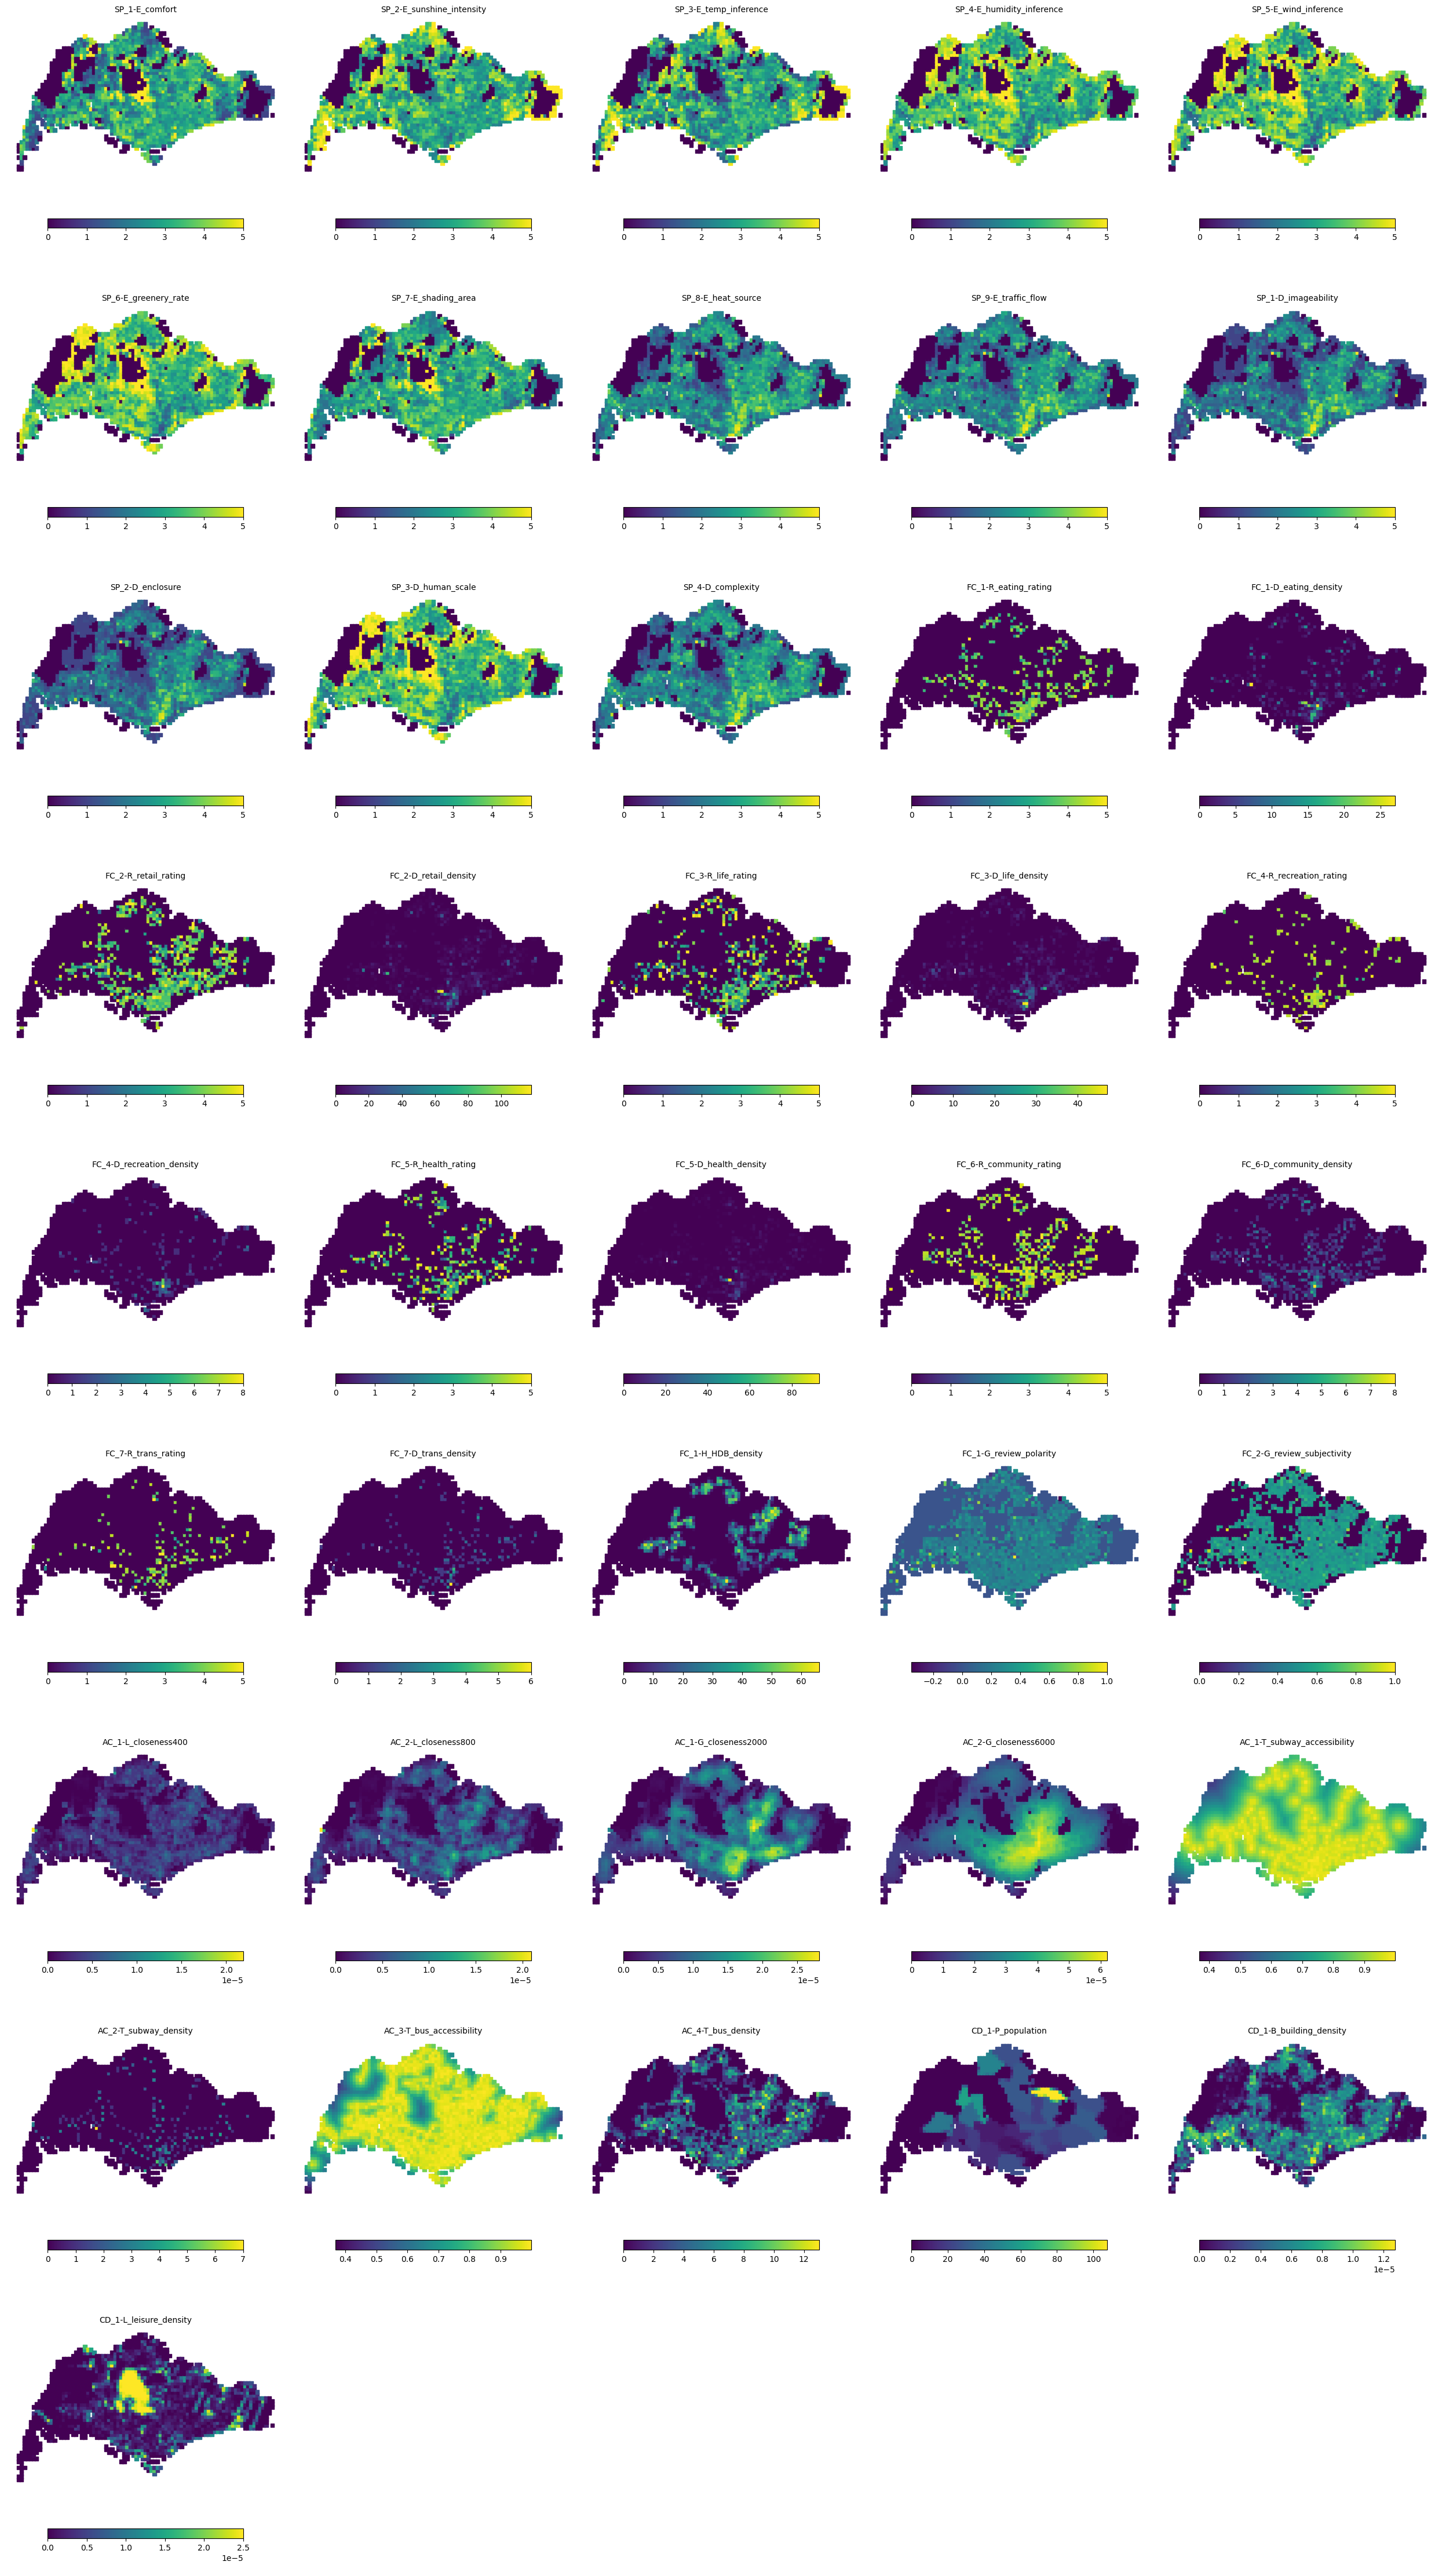

Visualized features: 41


In [10]:
# -------------------------
# 3B) Feature visualization (all features, single-pass)
# -------------------------

if "fx_df" not in globals():
    raise RuntimeError("Please run the Social Activity Field block first.")

feature_cols = [c for c in fx_available_features if c in fx_df.columns]
if not feature_cols:
    raise RuntimeError("No feature columns found for visualization.")

n_cols = 5
n_rows = int(len(feature_cols) / n_cols) + (len(feature_cols) % n_cols > 0)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

for i, col in enumerate(feature_cols):
    ax = axes.flat[i]
    fx_df.plot(
        ax=ax,
        column=col,
        marker="s",
        markersize=22,
        legend=True,
        cmap="viridis",
        legend_kwds={"orientation": "horizontal", "shrink": 0.7},
    )
    ax.set_title(col, fontsize=10)
    ax.axis("off")

for j in range(i + 1, n_rows * n_cols):
    axes.flat[j].axis("off")

plt.tight_layout()
plt.show()

print(f"Visualized features: {len(feature_cols)}")


In [11]:
# -------------------------
# 3C) Export activity field + original features to GPKG
# -------------------------
from pathlib import Path

FX_EXPORT_DIR = Path("data")
FX_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
FX_EXPORT_GPKG = FX_EXPORT_DIR / "data_uci_modelling.gpkg"

field_cols = [f"{act}_field" for act in FX_ACT_COLUMNS if f"{act}_field" in fx_gdf.columns]
feature_cols = [f for f in fx_available_features if f in fx_gdf.columns]

fx_export_cols = ["id", "longitude", "latitude"] + field_cols + feature_cols + ["geometry"]
fx_export_cols = [c for c in fx_export_cols if c in fx_gdf.columns]

if len(field_cols) == 0 or len(feature_cols) == 0:
    raise RuntimeError("Missing activity field columns or feature columns. Please run the extraction cells first.")

fx_export_gdf = fx_gdf[fx_export_cols].copy()
fx_export_gdf.to_file(FX_EXPORT_GPKG, driver="GPKG")

print(f"Exported: {FX_EXPORT_GPKG}")
print(f"Rows: {len(fx_export_gdf)}, Columns: {len(fx_export_gdf.columns)}")
print(f"Features: {len(feature_cols)}, Activity fields: {len(field_cols)}")
print("Exported columns:")
for col in fx_export_cols:
    print(f"  {col}")


Exported: data/data_uci_modelling.gpkg
Rows: 2096, Columns: 50
Features: 41, Activity fields: 5
Exported columns:
  id
  longitude
  latitude
  eating_field
  nature_field
  community_field
  walking_field
  sightseeing_field
  SP_1-E_comfort
  SP_2-E_sunshine_intensity
  SP_3-E_temp_inference
  SP_4-E_humidity_inference
  SP_5-E_wind_inference
  SP_6-E_greenery_rate
  SP_7-E_shading_area
  SP_8-E_heat_source
  SP_9-E_traffic_flow
  SP_1-D_imageability
  SP_2-D_enclosure
  SP_3-D_human_scale
  SP_4-D_complexity
  FC_1-R_eating_rating
  FC_1-D_eating_density
  FC_2-R_retail_rating
  FC_2-D_retail_density
  FC_3-R_life_rating
  FC_3-D_life_density
  FC_4-R_recreation_rating
  FC_4-D_recreation_density
  FC_5-R_health_rating
  FC_5-D_health_density
  FC_6-R_community_rating
  FC_6-D_community_density
  FC_7-R_trans_rating
  FC_7-D_trans_density
  FC_1-H_HDB_density
  FC_1-G_review_polarity
  FC_2-G_review_subjectivity
  AC_1-L_closeness400
  AC_2-L_closeness800
  AC_1-G_closeness2000
  AC